Cleaning up directory: runs...

🚀 Initializing clean testing pipeline...
>>> Processing CNN-1...

image 1/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/113.jpg: 640x640 (no detections), 7.7ms
image 2/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/119.jpg: 640x640 (no detections), 7.7ms
image 3/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/175.jpg: 640x640 1 book, 7.7ms
image 4/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/179.jpg: 640x640 (no detections), 7.7ms
image 5/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/228.jpg: 640x640 (no detections), 8.3ms
image 6/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/279.jpg: 640x640 (no detections), 7.7ms
image 7/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/286.jpg: 640x640 (no detections), 7.7ms
image 8/8 /home/sagemaker-user/42174_AI_Studio_Hajimi/processed_dataset/289.jpg: 640x640 (no detections), 7.7ms
Speed: 3.2ms pr

/tmp/ipykernel_16979/2105658230.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Config', y='Speed (ms)', data=df, palette='Blues_d', alpha=0.7)


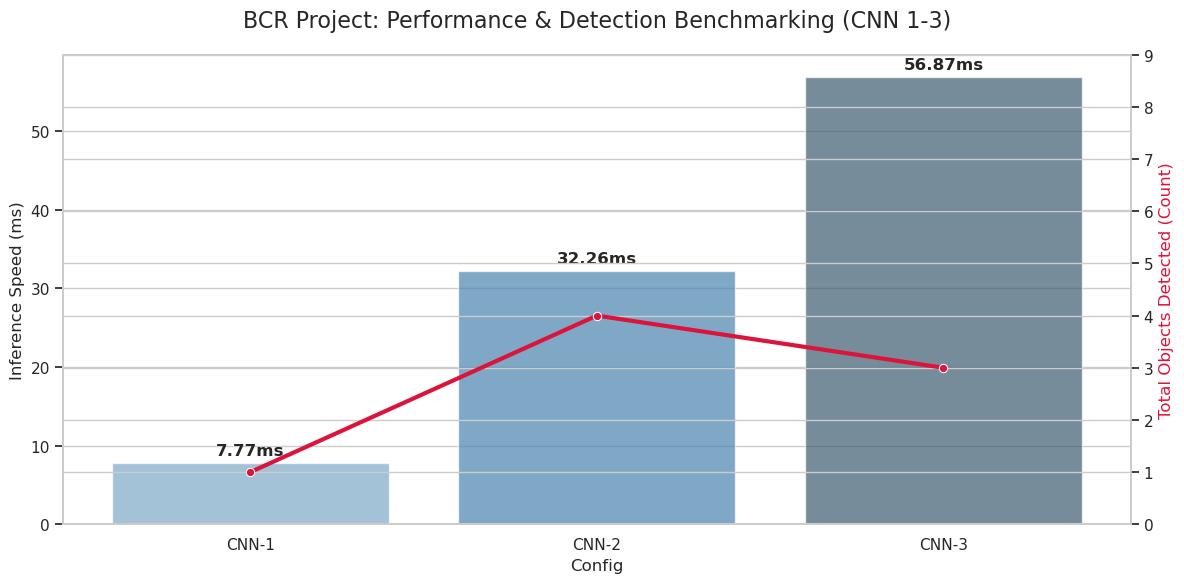


✅ Benchmarking completed successfully!
All output assets are stored in the unified directory: test-Result


In [4]:
import os
import shutil
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

# --- 1. Forceful Environment Cleanup (Remove Redundancies) ---
# Delete existing folders to prevent automatic naming increments like predict1, predict2.
folders_to_nuke = ['test-Result', 'runs', 'Model_Visual_Comparison']
for f in folders_to_nuke:
    if os.path.exists(f):
        print(f"Cleaning up directory: {f}...")
        shutil.rmtree(f)

# Recreate the main output directory
parent_folder = 'test-Result'
os.makedirs(parent_folder)

# --- 2. Model Configurations (Aligned with Project PPT) ---
configs = [
    {'id': 'CNN-1', 'name': 'CNN-1_n_640_NoAug', 'model_file': 'yolov8n.pt', 'imgsz': 640, 'augment': False},
    {'id': 'CNN-2', 'name': 'CNN-2_n_640_Aug', 'model_file': 'yolov8n.pt', 'imgsz': 640, 'augment': True},
    {'id': 'CNN-3', 'name': 'CNN-3_s_1024_Aug', 'model_file': 'yolov8s.pt', 'imgsz': 1024, 'augment': True}
]

# --- 3. Execute Benchmarking and Capture Metrics (Speed & Detection Count) ---
input_data = './processed_dataset'
performance_log = []

print(f"\n Initializing clean testing pipeline...")

for cfg in configs:
    print(f">>> Processing {cfg['id']}...")
    model = YOLO(cfg['model_file'])
    
    # Run inference: 'project' defines the parent folder, 'name' defines the sub-folder
    results = model.predict(
        source=input_data,
        imgsz=cfg['imgsz'],
        augment=cfg['augment'],
        conf=0.25,      # Maintain a low threshold to observe detection variances
        save=True,
        project=parent_folder,
        name=cfg['name'],
        exist_ok=True   # Overwrite existing folder to keep structure clean
    )
    
    # Calculate performance metrics
    avg_speed = np.mean([r.speed['inference'] for r in results])
    total_detections = sum(len(r.boxes) for r in results)
    
    performance_log.append({
        'Config': cfg['id'],
        'Speed (ms)': round(avg_speed, 2),
        'Detections': total_detections
    })

# --- 4. Data Visualization: Bar Chart (Speed) + Line Graph (Detections) ---
df = pd.DataFrame(performance_log)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Primary Axis: Blue Bar Chart for Inference Speed
ax1 = sns.barplot(x='Config', y='Speed (ms)', data=df, palette='Blues_d', alpha=0.7)
plt.title('BCR Project: Performance & Detection Benchmarking (CNN 1-3)', fontsize=16, pad=20)
plt.ylabel('Inference Speed (ms)', fontsize=12)

# Secondary Axis: Red Line Graph for Detection Count
ax2 = ax1.twinx()
sns.lineplot(x='Config', y='Detections', data=df, marker='o', color='crimson', linewidth=3, ax=ax2)
ax2.set_ylabel('Total Objects Detected (Count)', color='crimson', fontsize=12)
ax2.set_ylim(0, df['Detections'].max() + 5) # Provide headroom for the line graph

# Annotate bars with precise speed values (milliseconds)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}ms', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Benchmarking completed successfully!")
print(f"All output assets are stored in the unified directory: {parent_folder}")